### 1. Load a Pre-trained Model & Dataset:

#### We are using ResNet 50 as our pretrained model and CIFAR10 as thedataset


In [2]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

print(f"Train set: {x_train.shape}, Validation set: {x_valid.shape}, Test set: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train set: (40000, 32, 32, 3), Validation set: (10000, 32, 32, 3), Test set: (10000, 32, 32, 3)


#### We have added two dense layers to ResNet 50 model to make it with compatible with CIFAR10 which has 10 classes.

In [3]:
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras import Input

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(32, 32, 3))

x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(10, activation="softmax")(x)


model = Model(inputs=base_model.input, outputs=x)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### The model is fit to the data.

In [4]:
model.fit(x_train, y_train, epochs=25, batch_size=64, validation_data=(x_valid, y_valid))

# loss, accuracy_clean = model.evaluate(x_test, y_test, verbose=0)
# print(f"Accuracy on Clean Images: {accuracy_clean:.4f}")

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 45ms/step - accuracy: 0.4936 - loss: 1.5848 - val_accuracy: 0.2007 - val_loss: 2.4518
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.7165 - loss: 0.8449 - val_accuracy: 0.5818 - val_loss: 1.4198
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.7761 - loss: 0.6613 - val_accuracy: 0.5844 - val_loss: 1.2830
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.7849 - loss: 0.6302 - val_accuracy: 0.6539 - val_loss: 1.2169
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8369 - loss: 0.4831 - val_accuracy: 0.6876 - val_loss: 1.0712
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8684 - loss: 0.3922 - val_accuracy: 0.6884 - val_loss: 1.1334
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8883 - loss: 0.3324 - val_accuracy: 0.6861 - val_loss: 1.1324
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9026 - loss: 0.2940 - 

In [5]:
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_valid, y_valid))

loss, accuracy_clean = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy on Clean Images: {accuracy_clean:.4f}")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9763 - loss: 0.0761 - val_accuracy: 0.7245 - val_loss: 1.4970
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9821 - loss: 0.0524 - val_accuracy: 0.7598 - val_loss: 1.2646
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9812 - loss: 0.0602 - val_accuracy: 0.7503 - val_loss: 1.3225
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9834 - loss: 0.0508 - val_accuracy: 0.6908 - val_loss: 1.6357
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9829 - loss: 0.0541 - val_accuracy: 0.7524 - val_loss: 1.3471
Accuracy on Clean Images: 0.7435


### 2. Implement Adversarial Attacks:



#### Install the ART toolbox if already not installed!

In [6]:
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.1 MB/s eta 0:00:0000:010:01


In [8]:
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent

In [9]:
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=10,
    input_shape=(32, 32, 3),
    loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(0, 1)
)

In [10]:
from tqdm import tqdm

#### Implementation of FGSM with batches of testing data, since transferring the whole image leads to GPU error!

In [11]:
fgsm = FastGradientMethod(estimator=classifier, eps=0.02)

batch_size = 128
x_test_adv_fgsm = np.zeros_like(x_test)

for i in tqdm(range(0, len(x_test), batch_size)):
    x_batch = x_test[i : i + batch_size]
    x_test_adv_fgsm[i : i + batch_size] = fgsm.generate(x=x_batch)

print("FGSM attack completed!")

100%|██████████| 79/79 [02:46<00:00,  2.10s/it]

FGSM attack completed!


#### Implementation of PGD with batches of testing data.

In [12]:
pgd = ProjectedGradientDescent(estimator=classifier, eps=0.03, eps_step=0.02, max_iter=3)

x_test_adv_pgd = np.zeros_like(x_test)

for i in tqdm(range(0, len(x_test), batch_size)):
    x_batch = x_test[i : i + batch_size]
    x_test_adv_pgd[i : i + batch_size] = pgd.generate(x=x_batch)

print("PGD attack completed!")

  0%|          | 0/79 [00:00<?, ?it/s]

PGD - Batches: 0it [00:00, ?it/s]

  1%|▏         | 1/79 [00:08<10:55,  8.40s/it]

PGD - Batches: 0it [00:00, ?it/s]

  3%|▎         | 2/79 [00:14<09:07,  7.12s/it]

...

PGD - Batches: 0it [00:00, ?it/s]

 99%|█████████▊| 78/79 [08:06<00:06,  6.19s/it]

PGD - Batches: 0it [00:00, ?it/s]

100%|██████████| 79/79 [08:08<00:00,  6.18s/it]

PGD attack completed!


### 3. Visualization & Analysis:

#### Compute the accuracy of model with respect to clean, FGSM attacked images and PGD attacked images.

In [13]:
acc_clean = np.mean(np.argmax(classifier.predict(x_test), axis=1) == np.argmax(y_test, axis=1))

acc_fgsm = np.mean(np.argmax(classifier.predict(x_test_adv_fgsm), axis=1) == np.argmax(y_test, axis=1))

acc_pgd = np.mean(np.argmax(classifier.predict(x_test_adv_pgd), axis=1) == np.argmax(y_test, axis=1))

#### Bar-plot of accuracy of the model with respect to clean, FGSM attacked images and PGD attacked images.

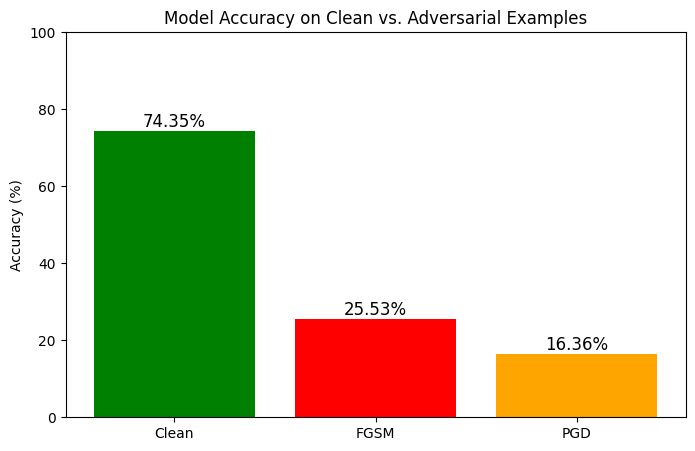

In [14]:
import matplotlib.pyplot as plt

accuracies = [acc_clean * 100, acc_fgsm * 100, acc_pgd * 100]
labels = ["Clean", "FGSM", "PGD"]

plt.figure(figsize=(8, 5))
plt.bar(labels, accuracies, color=["green", "red", "orange"])
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy on Clean vs. Adversarial Examples")

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha="center", fontsize=12)

plt.show()

#### Plot of a clean image, clean image attacked with FGSM and the clean image attacked by PGD.

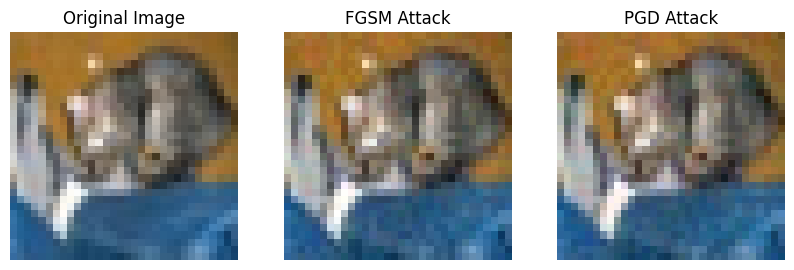

In [15]:
sample_idx = 0
x_orig, x_fgsm, x_pgd = x_test[sample_idx], x_test_adv_fgsm[sample_idx], x_test_adv_pgd[sample_idx]

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(x_orig)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_fgsm)
plt.title("FGSM Attack")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(x_pgd)
plt.title("PGD Attack")
plt.axis("off")

plt.show()



Insights & Analysis


1.   Impact of Adversarial Attacks on Performance
   * The bar chart shows a significant accuracy drop on adversarial examples.
   * FGSM attack slightly reduces accuracy, while PGD attack is more severe.
   * This aligns with the fact that FGSM is a single-step attack, while PGD is iterative, making it more powerful.



2.   Observed Patterns & Model Vulnerabilities
   * Adversarial images look similar to human eyes but mislead the model.
   * The model is more vulnerable to PGD since it is designed to find stronger perturbations.
   * Certain classes (e.g., animals like cats/dogs) may be more affected than others, which could indicate class-wise robustness differences.

3.   Suggested Mitigation Strategies
   * Adversarial Training:	Train on adversarial examples (FGSM & PGD) to
make the model robust.
   * Defensive Distillation:	Train a secondary model that smoothens the decision boundaries.
   * Input Preprocessing:	Apply Gaussian noise, feature squeezing, or JPEG compression to remove adversarial perturbations.
   * Detection Mechanisms:	Identify adversarial examples before feeding them into the model.


### 4. Mitigation Exploration:

#### We use adversarial training to mitigate a adversarial attacks. Here, we have concatenated clean image with the images attacked with fgsm and then fit the model.

In [16]:
import numpy as np

x_train_adv_fgsm = np.zeros_like(x_train)

batch_size = 64  
for i in tqdm(range(0, len(x_train), batch_size)):
    x_batch = x_train[i : i + batch_size]
    x_train_adv_fgsm[i : i + batch_size] = fgsm.generate(x=x_batch)

x_train_combined = np.concatenate([x_train, x_train_adv_fgsm])
y_train_combined = np.concatenate([y_train, y_train])

In [32]:
x_valid_adv_fgsm = np.zeros_like(x_valid)

batch_size = 100
for i in tqdm(range(0, len(x_valid), batch_size)):
    x_batch = x_valid[i : i + batch_size]
    x_valid_adv_fgsm[i : i + batch_size] = fgsm.generate(x=x_batch)

x_valid_combined = np.concatenate([x_valid, x_valid_adv_fgsm])
y_valid_combined = np.concatenate([y_valid, y_valid])

100%|██████████| 100/100 [03:27<00:00,  2.07s/it]


In [33]:
model_adversarial = ResNet50(weights="imagenet", include_top=False, input_shape=(32, 32, 3))

x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(10, activation="softmax")(x)


model_adversarial = Model(inputs=base_model.input, outputs=x)

model_adversarial.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


In [34]:
model_adversarial.fit(x_train_combined, y_train_combined, 
                      epochs=10, batch_size=64, validation_data=(x_valid_combined, y_valid_combined))

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 91s 41ms/step - accuracy: 0.9370 - loss: 0.2376 - val_accuracy: 0.6332 - val_loss: 1.9782
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.9826 - loss: 0.0552 - val_accuracy: 0.6029 - val_loss: 2.5273
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.9827 - loss: 0.0531 - val_accuracy: 0.6388 - val_loss: 2.2788
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.9757 - loss: 0.0769 - val_accuracy: 0.6360 - val_loss: 2.1343
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.9794 - loss: 0.0673 - val_accuracy: 0.6518 - val_loss: 1.9995
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.9831 - loss: 0.0525 - val_accuracy: 0.6535 - val_loss: 2.0616
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.9827 - loss: 0.0518 - val_accuracy: 0.6531 - val_loss: 2.1148
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.9466 -

In [35]:
acc_clean_adv = model_adversarial.evaluate(x_test, y_test, verbose=0)[1]
acc_fgsm_adv = model_adversarial.evaluate(x_test_adv_fgsm, y_test, verbose=0)[1]
acc_pgd_adv = model_adversarial.evaluate(x_test_adv_pgd, y_test, verbose=0)[1]

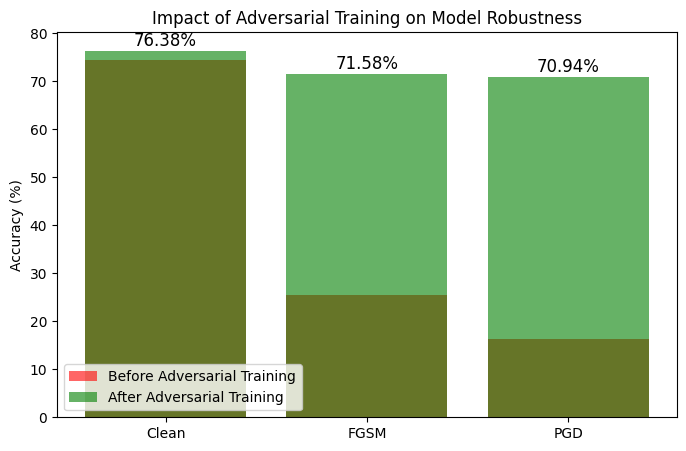

In [37]:
import matplotlib.pyplot as plt

accuracies_before = [acc_clean * 100, acc_fgsm * 100, acc_pgd * 100]
accuracies_after = [acc_clean_adv * 100, acc_fgsm_adv * 100, acc_pgd_adv * 100]
labels = ["Clean", "FGSM", "PGD"]

plt.figure(figsize=(8, 5))
plt.bar(labels, accuracies_before, color="red", alpha=0.6, label="Before Adversarial Training")
plt.bar(labels, accuracies_after, color="green", alpha=0.6, label="After Adversarial Training")
plt.ylabel("Accuracy (%)")
plt.title("Impact of Adversarial Training on Model Robustness")
plt.legend(loc="lower left")

for i, acc in enumerate(accuracies_after):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha="center", fontsize=12)

plt.show()

#### As we can infer from the above figure, with adversarial training we could make the model more robust towards both FGSM and PGD attacks.

### 5. Transferability Analysis of Adversarial Examples:

#### We have used a new model: VGG16 which is our target model, and checked wether the images attacked with fgsm from a source model(ResNet 50) reduce the accuracy of VGG16 model

In [38]:
from tensorflow.keras.applications import VGG16

In [41]:
base_vgg = VGG16(weights="imagenet", include_top=False, input_shape=(32, 32, 3))

x = Flatten()(base_vgg.output)
x = Dense(256, activation="relu")(x)
x = Dense(10, activation="softmax")(x)


vgg_model = Model(inputs=base_vgg.input, outputs=x)

vgg_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [42]:
vgg_model.fit(x_train, y_train, epochs=25, batch_size=64, validation_data=(x_valid, y_valid))

loss, accuracy_clean = vgg_model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy on Clean Images: {accuracy_clean:.4f}")

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.1774 - loss: 2.1019 - val_accuracy: 0.3076 - val_loss: 1.7126
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.3533 - loss: 1.6140 - val_accuracy: 0.4728 - val_loss: 1.3496
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5068 - loss: 1.2885 - val_accuracy: 0.5991 - val_loss: 1.1425
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.6314 - loss: 1.0295 - val_accuracy: 0.6587 - val_loss: 0.9591
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.6993 - loss: 0.8760 - val_accuracy: 0.7037 - val_loss: 0.8733
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7492 - loss: 0.7463 - val_accuracy: 0.7224 - val_loss: 0.8684
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7823 - loss: 0.6518 - val_accuracy: 0.7508 - val_loss: 0.7939
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.8039 - loss: 0.5941 - 

In [44]:
acc_target_clean = vgg_model.evaluate(x_test, y_test, verbose=0)[1]
acc_target_adv = vgg_model.evaluate(x_test_adv_fgsm, y_test, verbose=0)[1]

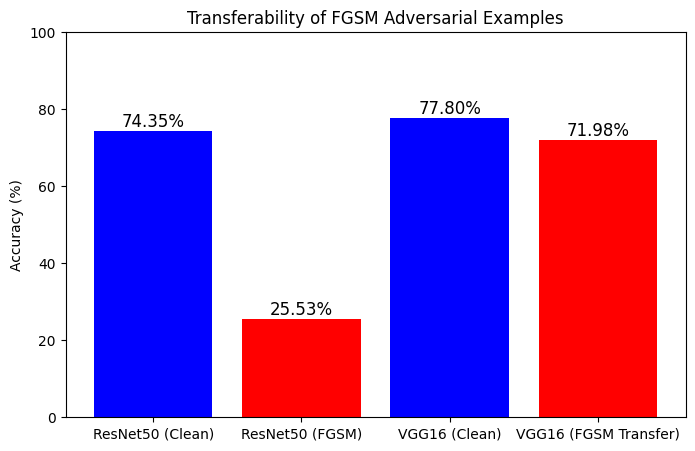

In [46]:
models = ["ResNet50 (Clean)", "ResNet50 (FGSM)", "VGG16 (Clean)", "VGG16 (FGSM Transfer)"]
accuracies = [acc_clean * 100, acc_fgsm * 100, acc_target_clean * 100, acc_target_adv * 100]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=["blue", "red", "blue", "red"])
plt.ylabel("Accuracy (%)")
plt.title("Transferability of FGSM Adversarial Examples")
plt.ylim(0, 100)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha="center", fontsize=12)

plt.show()

#### FGSM examples crafted for ResNet50 don’t fool VGG16 as easily. VGG16 still performs at 71.98%, meaning adversarial examples don’t transfer well across architectures. This suggests that FGSM examples are model-dependent (not universal adversarial examples).